In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, auc, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# SSL fix for macOS
import ssl
import certifi
import urllib.request

context = ssl.create_default_context(cafile=certifi.where())
def install_opener():
    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
    urllib.request.install_opener(opener)

install_opener()

In [6]:
# ============================================
# LOAD AND PREPARE DATA
# ============================================
from ucimlrepo import fetch_ucirepo

print("Fetching PhiUSIIL Phishing URL Dataset...")
phiusiil = fetch_ucirepo(id=967)

# Organize data
X = phiusiil.data.features
y = phiusiil.data.targets
df = pd.concat([X, y], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Get label column
label_col = [col for col in df.columns if 'label' in col.lower()][-1]

# Keep only numeric features and drop the URL column
X = df.select_dtypes(include=[np.number]).drop(columns=[label_col])
y = df[label_col]

print(f"\nNumeric Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Class distribution:\n{y.value_counts()}")

Fetching PhiUSIIL Phishing URL Dataset...
Dataset shape: (235795, 55)
Missing values: 0

Numeric Features: 50
Samples: 235795
Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64


In [7]:
# ============================================
# TRAIN-TEST SPLIT AND SCALING
# ============================================

# Split data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled successfully")
print(f"Training set class distribution:\n{pd.Series(y_train).value_counts()}")

Training set size: 188636
Test set size: 47159

Features scaled successfully
Training set class distribution:
label
1    107880
0     80756
Name: count, dtype: int64


In [8]:
# ============================================
# LOGISTIC REGRESSION
# ============================================
print("="*60)
print("LOGISTIC REGRESSION BASELINE")
print("="*60)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred_lr):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba_lr):.4f}")

# Top coefficients
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nTop 10 Most Important Features (by coefficient):")
print(feature_importance_lr.head(10))

LOGISTIC REGRESSION BASELINE

Training Accuracy: 0.9999
Test Accuracy: 0.9999
Test Precision: 0.9998
Test Recall: 1.0000
Test F1-Score: 0.9999
Test ROC-AUC: 1.0000

Top 10 Most Important Features (by coefficient):
                  feature  coefficient
3      URLSimilarityIndex     7.144740
21                IsHTTPS     3.910232
20  SpacialCharRatioInURL    -1.888559
13       LetterRatioInURL    -1.750995
47            NoOfSelfRef     1.637538
46                 NoOfJS     1.598587
36           HasSocialNet     1.485065
49        NoOfExternalRef     1.428235
44              NoOfImage     1.336070
15        DegitRatioInURL    -1.269880


In [9]:
# ============================================
# RANDOM FOREST
# ============================================
print("="*60)
print("RANDOM FOREST BASELINE")
print("="*60)

# Train Random Forest (using original unscaled data)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba_rf):.4f}")

# Feature importances
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance_rf.head(10))

RANDOM FOREST BASELINE

Training Accuracy: 1.0000
Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1-Score: 1.0000
Test ROC-AUC: 1.0000

Top 10 Most Important Features:
               feature  importance
3   URLSimilarityIndex    0.181473
49     NoOfExternalRef    0.165074
22          LineOfCode    0.145753
47         NoOfSelfRef    0.107257
44           NoOfImage    0.091632
46              NoOfJS    0.069520
45             NoOfCSS    0.032895
36        HasSocialNet    0.032432
43    HasCopyrightInfo    0.026523
21             IsHTTPS    0.021636


MODEL COMPARISON

   Metric  Logistic Regression  Random Forest
 Accuracy             0.999873            1.0
Precision             0.999778            1.0
   Recall             1.000000            1.0
 F1-Score             0.999889            1.0
  ROC-AUC             1.000000            1.0


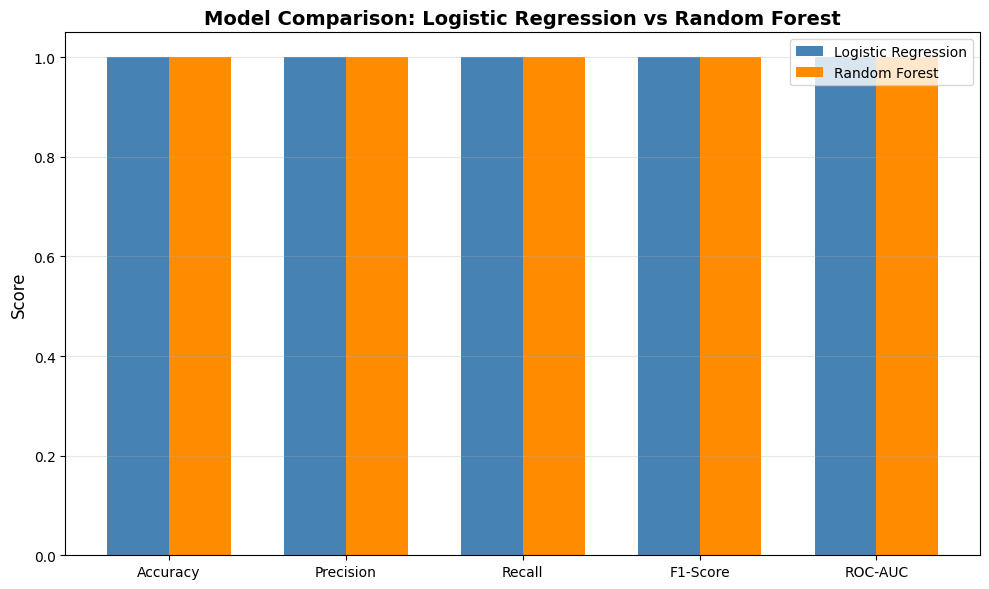

In [10]:
# ============================================
# MODEL COMPARISON
# ============================================
print("="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_lr),
        roc_auc_score(y_test, y_test_pred_proba_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_rf),
        recall_score(y_test, y_test_pred_rf),
        f1_score(y_test, y_test_pred_rf),
        roc_auc_score(y_test, y_test_pred_proba_rf)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{comparison_df.to_string(index=False)}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Logistic Regression'], width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, comparison_df['Random Forest'], width, label='Random Forest', color='darkorange')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

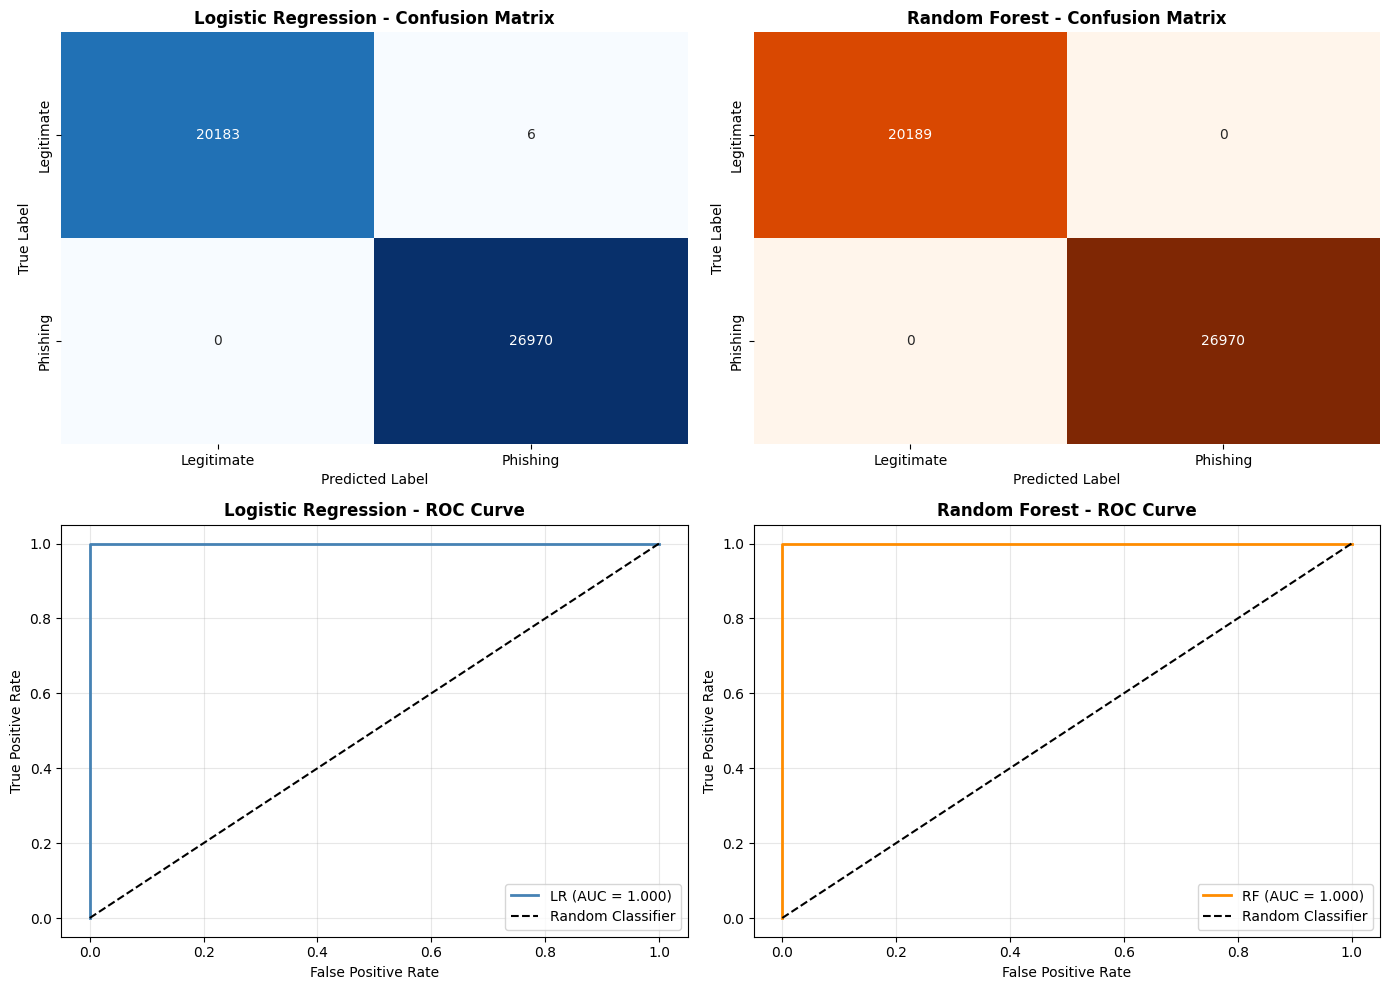

In [11]:
# ============================================
# CONFUSION MATRICES AND ROC CURVES
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_xticklabels(['Legitimate', 'Phishing'])
axes[0, 0].set_yticklabels(['Legitimate', 'Phishing'])

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Random Forest - Confusion Matrix', fontweight='bold')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_xticklabels(['Legitimate', 'Phishing'])
axes[0, 1].set_yticklabels(['Legitimate', 'Phishing'])

# ROC Curve - Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
axes[1, 0].plot(fpr_lr, tpr_lr, label=f'LR (AUC = {auc_lr:.3f})', color='steelblue', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Logistic Regression - ROC Curve', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ROC Curve - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
axes[1, 1].plot(fpr_rf, tpr_rf, label=f'RF (AUC = {auc_rf:.3f})', color='darkorange', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('Random Forest - ROC Curve', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# ECONOMIC COST ANALYSIS
# ============================================
print("="*60)
print("ECONOMIC COST OF MISCLASSIFICATION")
print("="*60)

# Define costs
cost_fp = 100  # False Positive: Block legitimate user (revenue loss, friction)
cost_fn = 500  # False Negative: Allow phishing (data breach, ransomware)

print(f"\nCost Matrix:")
print(f"  False Positive (Type I): ${cost_fp} (block legitimate user)")
print(f"  False Negative (Type II): ${cost_fn} (allow phishing)")

# Calculate costs for both models at threshold = 0.5
def calculate_economic_cost(y_true, cm, cost_fp, cost_fn):
    """Calculate total economic cost from confusion matrix"""
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    return total_cost, fp, fn

cost_lr, fp_lr, fn_lr = calculate_economic_cost(y_test, cm_lr, cost_fp, cost_fn)
cost_rf, fp_rf, fn_rf = calculate_economic_cost(y_test, cm_rf, cost_fp, cost_fn)

print(f"\n{'Model':<20} {'Cost':<15} {'FP':<10} {'FN':<10}")
print("-" * 55)
print(f"{'Logistic Regression':<20} ${cost_lr:<14} {fp_lr:<10} {fn_lr:<10}")
print(f"{'Random Forest':<20} ${cost_rf:<14} {fp_rf:<10} {fn_rf:<10}")

print(f"\nEconomic savings (RF vs LR): ${max(0, cost_lr - cost_rf)}")
print(f"Better model: {'Random Forest' if cost_rf < cost_lr else 'Logistic Regression'}")

ECONOMIC COST OF MISCLASSIFICATION

Cost Matrix:
  False Positive (Type I): $100 (block legitimate user)
  False Negative (Type II): $500 (allow phishing)

Model                Cost            FP         FN        
-------------------------------------------------------
Logistic Regression  $600            6          0         
Random Forest        $0              0          0         

Economic savings (RF vs LR): $600
Better model: Random Forest



OPTIMAL THRESHOLD ANALYSIS

Logistic Regression:
  Optimal Threshold: 0.798
  Minimum Economic Cost: $200

Random Forest:
  Optimal Threshold: 0.444
  Minimum Economic Cost: $0


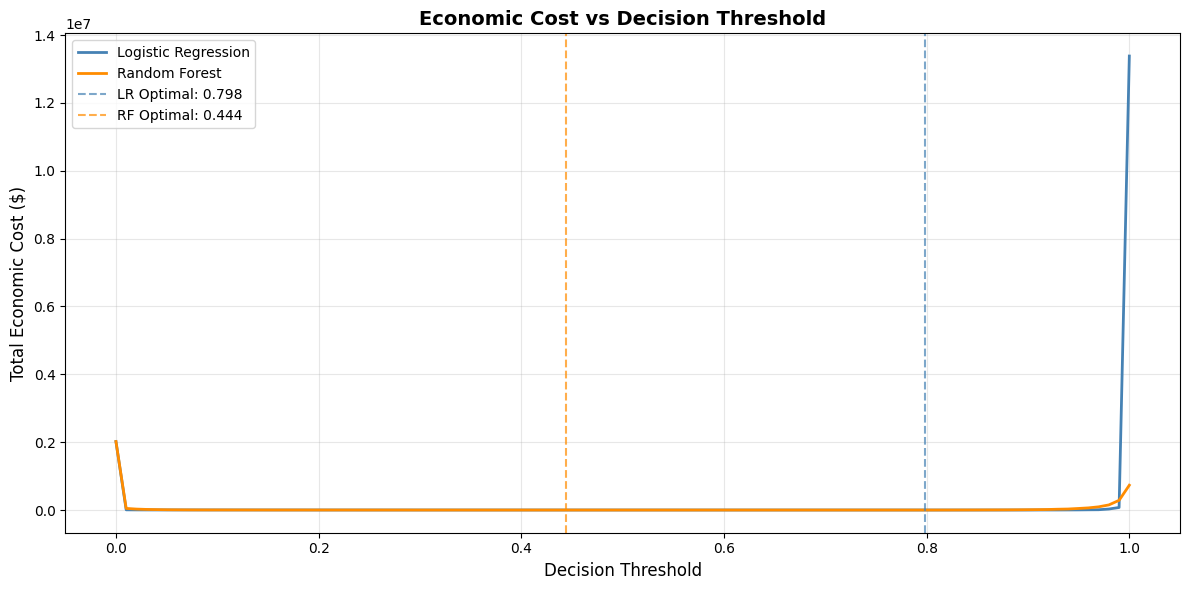

In [13]:
# ============================================
# OPTIMAL THRESHOLD ANALYSIS
# ============================================
print("\n" + "="*60)
print("OPTIMAL THRESHOLD ANALYSIS")
print("="*60)

# Find optimal thresholds based on economic cost
thresholds = np.linspace(0, 1, 100)
costs_lr_threshold = []
costs_rf_threshold = []

for threshold in thresholds:
    # Logistic Regression
    y_pred_lr_thresh = (y_test_pred_proba_lr >= threshold).astype(int)
    cm_lr_thresh = confusion_matrix(y_test, y_pred_lr_thresh)
    cost_lr_thresh, _, _ = calculate_economic_cost(y_test, cm_lr_thresh, cost_fp, cost_fn)
    costs_lr_threshold.append(cost_lr_thresh)
    
    # Random Forest
    y_pred_rf_thresh = (y_test_pred_proba_rf >= threshold).astype(int)
    cm_rf_thresh = confusion_matrix(y_test, y_pred_rf_thresh)
    cost_rf_thresh, _, _ = calculate_economic_cost(y_test, cm_rf_thresh, cost_fp, cost_fn)
    costs_rf_threshold.append(cost_rf_thresh)

optimal_threshold_lr = thresholds[np.argmin(costs_lr_threshold)]
optimal_threshold_rf = thresholds[np.argmin(costs_rf_threshold)]
min_cost_lr = min(costs_lr_threshold)
min_cost_rf = min(costs_rf_threshold)

print(f"\nLogistic Regression:")
print(f"  Optimal Threshold: {optimal_threshold_lr:.3f}")
print(f"  Minimum Economic Cost: ${min_cost_lr}")

print(f"\nRandom Forest:")
print(f"  Optimal Threshold: {optimal_threshold_rf:.3f}")
print(f"  Minimum Economic Cost: ${min_cost_rf}")

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(thresholds, costs_lr_threshold, label='Logistic Regression', color='steelblue', linewidth=2)
plt.plot(thresholds, costs_rf_threshold, label='Random Forest', color='darkorange', linewidth=2)
plt.axvline(optimal_threshold_lr, color='steelblue', linestyle='--', alpha=0.7, label=f'LR Optimal: {optimal_threshold_lr:.3f}')
plt.axvline(optimal_threshold_rf, color='darkorange', linestyle='--', alpha=0.7, label=f'RF Optimal: {optimal_threshold_rf:.3f}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Economic Cost ($)', fontsize=12)
plt.title('Economic Cost vs Decision Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()